In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

Loading the dataset

In [2]:
#creating database connection
conn=sqlite3.connect('inventory.db')
#fetching vendor summary data
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,60320,1584606.40,344712.22,64889.97,9578.0,17598.14,68601.68,-1239894.18,-3.596897,0.006044,0.217538
1,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,22.99,96073,1553500.41,444810.74,43304.31,20226.0,37163.76,257032.07,-1108689.67,-2.492498,0.013020,0.286328
2,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,62385,1446708.15,275162.97,52289.50,9203.0,16909.12,144929.24,-1171545.18,-4.257641,0.006361,0.190199
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,75385,1375022.40,288135.11,48202.30,11189.0,20557.97,123780.22,-1086887.29,-3.772145,0.008137,0.209549
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,29.99,58783,1286759.87,357759.17,52774.51,11883.0,21833.58,257032.07,-929000.70,-2.596721,0.009235,0.278031


Exploratory data analysis

In [3]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,8512.0,10153.455122,17718.122212,2.000000e+00,3664.000000,7153.000000,9552.000000,1.733570e+05
Brand,8512.0,17600.258694,13004.702546,5.800000e+01,5297.750000,17432.500000,24988.000000,9.063100e+04
PurchasePrice,8512.0,21.889769,105.829821,3.600000e-01,6.800000,10.270000,18.240000,5.681810e+03
Volume,8512.0,854.875646,617.982459,5.000000e+01,750.000000,750.000000,750.000000,2.000000e+04
ActualPrice,8512.0,32.188422,144.210224,4.900000e-01,10.990000,15.990000,26.990000,7.499990e+03
TotalPurchaseQuantity,8512.0,1691.843633,5496.001551,1.000000e+00,24.000000,231.500000,1195.000000,1.607350e+05
TotalPurchaseDollars,8512.0,15786.558580,56938.194190,7.100000e-01,344.880000,2840.535000,12601.875000,1.584606e+06
TotalSalesDollars,6879.0,4792.547178,14916.313478,1.980000e+00,286.240000,1206.660000,4233.990000,4.448107e+05
TotalSalesPrice,6879.0,2339.093005,4661.874594,9.800000e-01,143.880000,689.320000,2564.610000,6.488997e+04
TotalSalesQuantity,6879.0,355.398168,1065.194898,1.000000e+00,14.000000,67.000000,288.000000,2.854400e+04


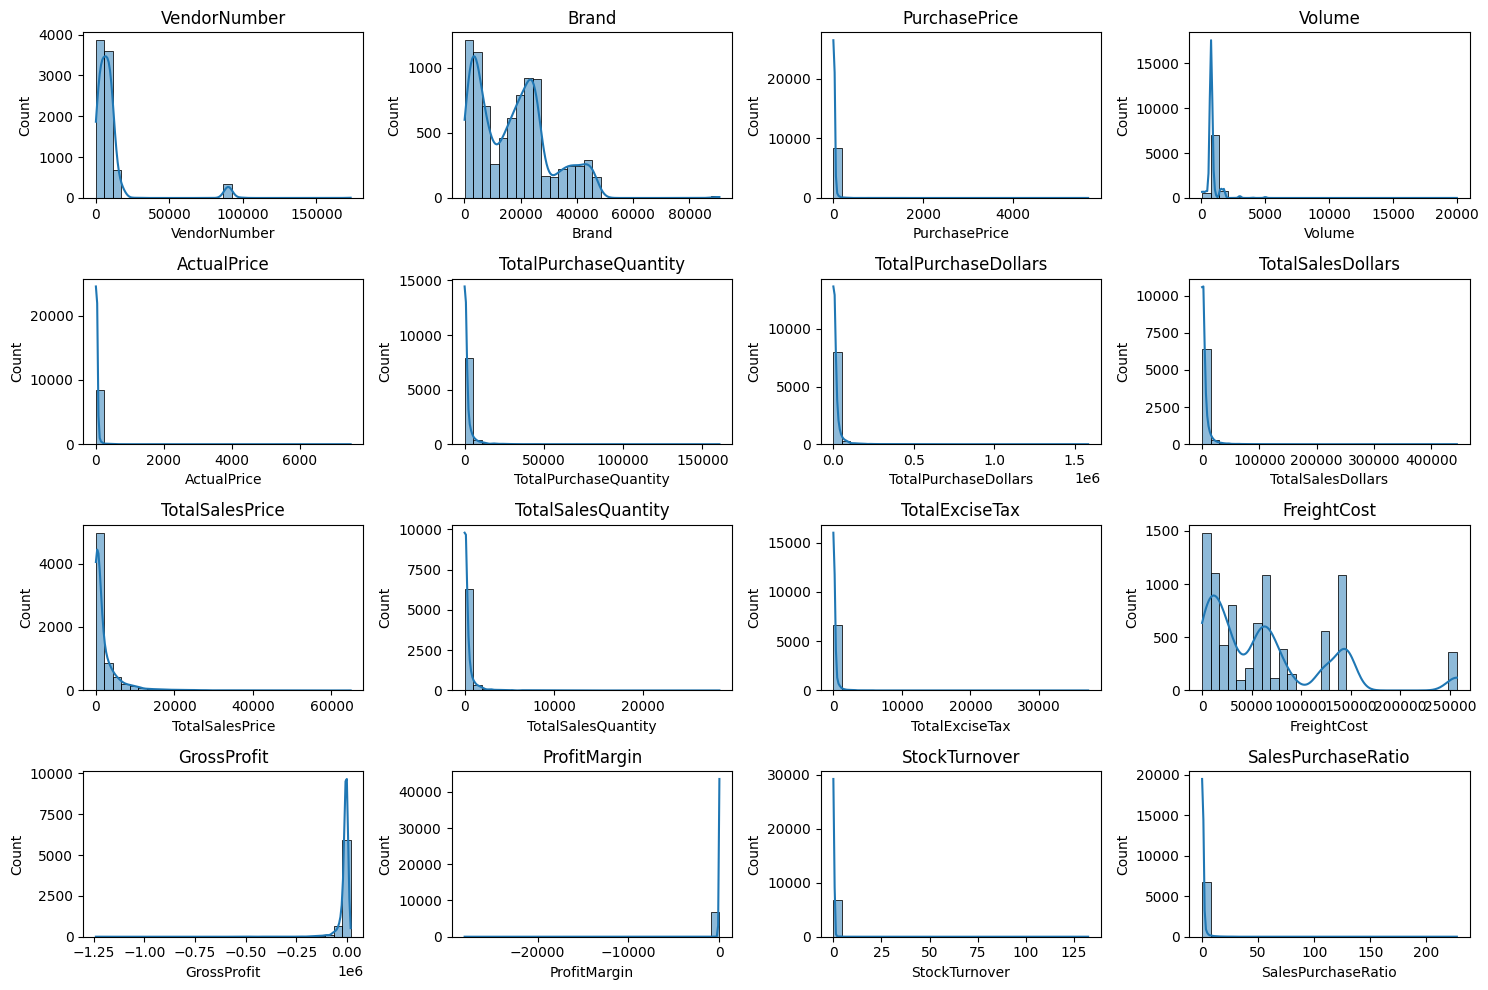

In [4]:
#DISTRIBUTION PLOTS for numerical columns
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) #adjust grid layout as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()    



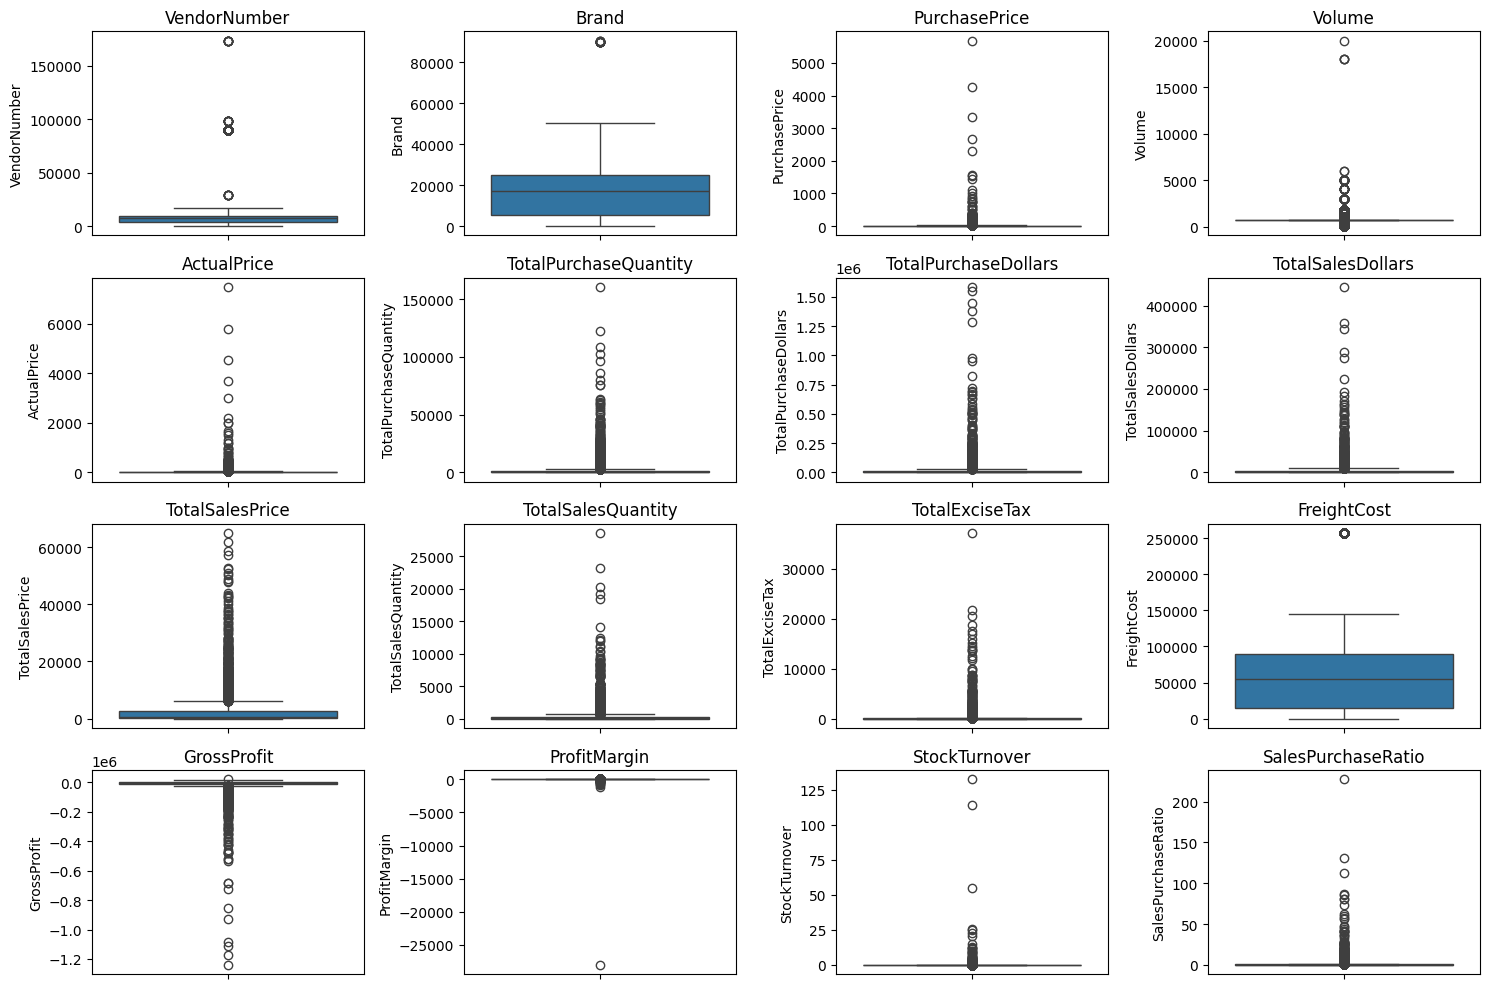

In [5]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) #adjust grid layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()    

In [6]:
#let's filter the data by removing incinsistencies
df=pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0                     
AND ProfitMargin > 0
AND TotalSalesQuantity > 0  """,conn)

In [7]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1392,CONSTELLATION BRANDS INC,6650,Simi Chard,7.38,750.0,14.99,11199,82648.62,93369.42,13558.87,8458.0,949.79,79528.99,10720.80,0.114821,0.102337,1.129715
1,1392,CONSTELLATION BRANDS INC,22143,Simi Cab Svgn,10.52,750.0,18.99,4194,44120.88,46523.13,13703.56,2887.0,323.21,79528.99,2402.25,0.051636,0.065434,1.054447
2,516,BANFI PRODUCTS CORP,18152,Banfi Centine Mntcln Tscna,5.26,750.0,10.99,5723,30102.98,31728.09,7605.68,3891.0,436.17,8510.41,1625.11,0.051220,0.129256,1.053985
3,10754,PERFECTA WINES,25197,Ch La Rousseliere St Estephe,99.33,750.0,149.99,249,24733.17,29698.02,1199.92,198.0,22.24,28720.52,4964.85,0.167178,0.008005,1.200737
4,4425,MARTIGNETTI COMPANIES,8781,Rodney Strong Cab Svgn,10.32,750.0,15.99,2241,23127.12,31245.60,11934.97,1840.0,205.53,144929.24,8118.48,0.259828,0.079560,1.351037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,90024,VINILANDIA USA,46135,Aresti Pnt Nr Curico Vly,3.28,750.0,10.99,1,3.28,74.85,39.92,15.0,1.68,2802.64,71.57,0.956179,4.573171,22.820122
978,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,750.0,4.99,2,2.64,5.97,5.97,3.0,0.33,27100.41,3.33,0.557789,1.136364,2.261364
979,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,50.0,0.49,6,2.34,62.72,0.98,128.0,6.72,50293.62,60.38,0.962691,54.700855,26.803419
980,9815,WINE GROUP INC,22407,Three Wishes Chard,2.25,750.0,3.29,1,2.25,3.29,3.29,1.0,0.11,27100.41,1.04,0.316109,0.444444,1.462222


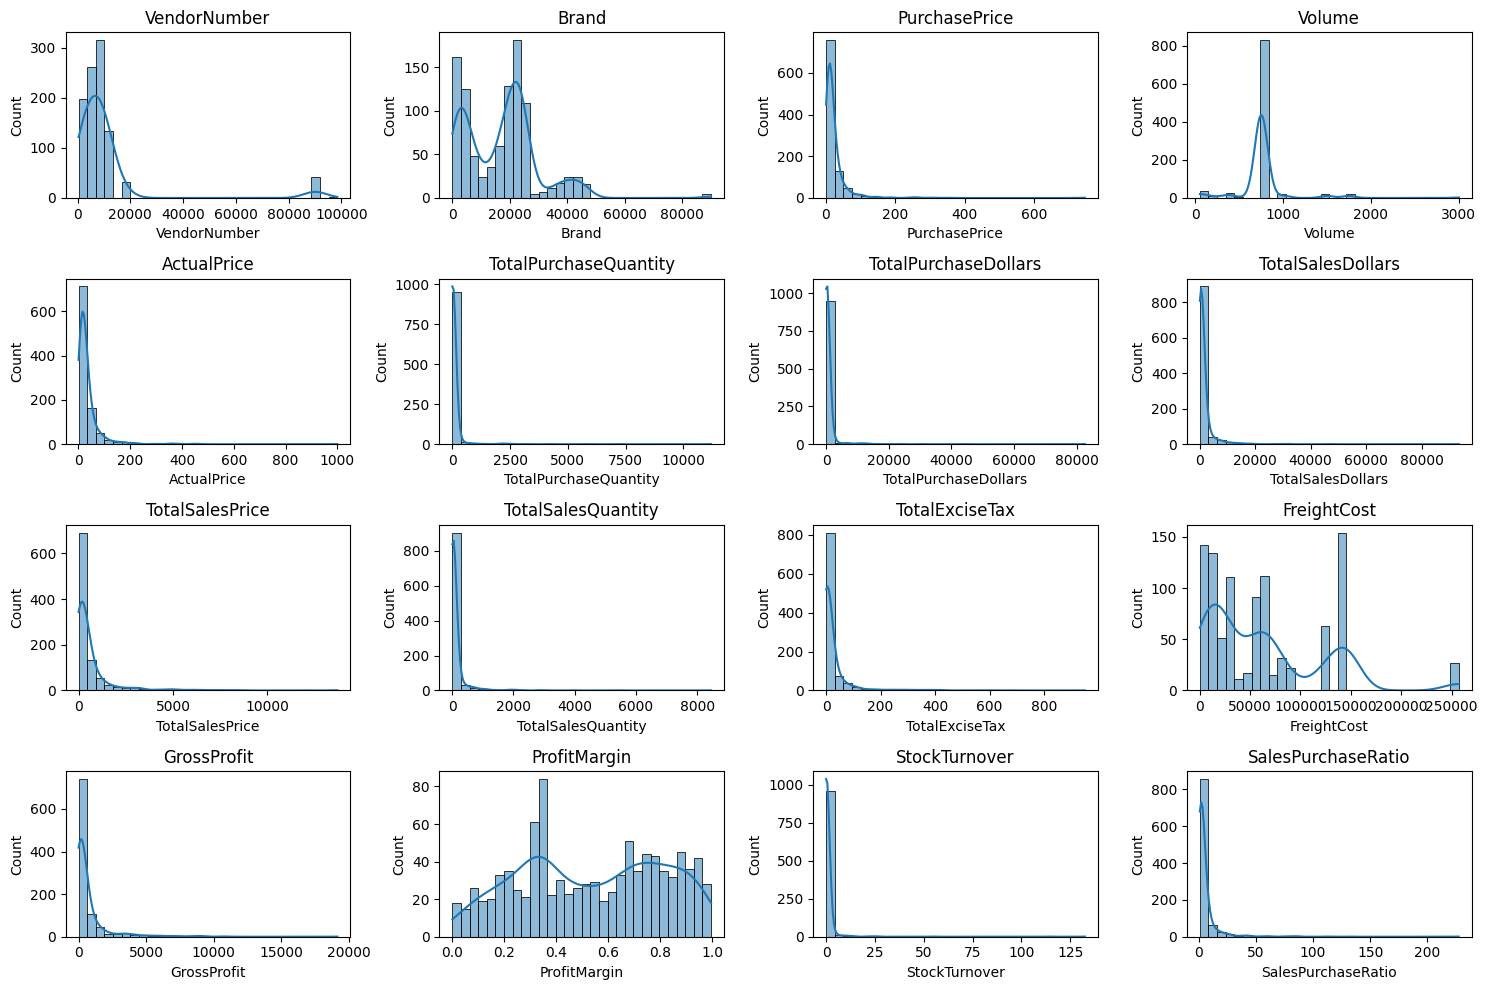

In [8]:
#DISTRIBUTION PLOTS for numerical columns
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) #adjust grid layout as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()    

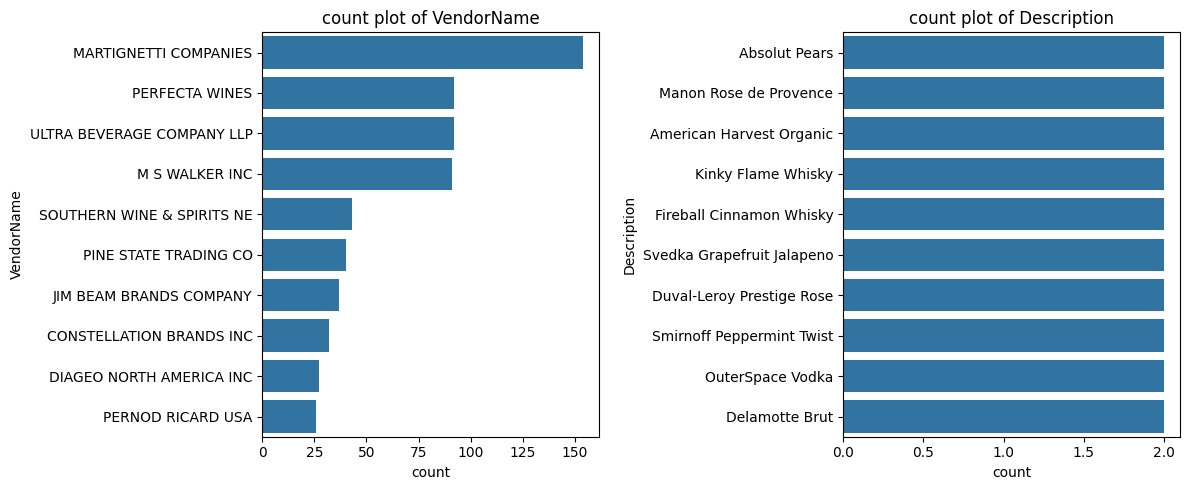

In [9]:
#count plots for categorical columns
categorical_cols =["VendorName","Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1) #adjust grid layout as needed
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) #top 10 categories
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()    

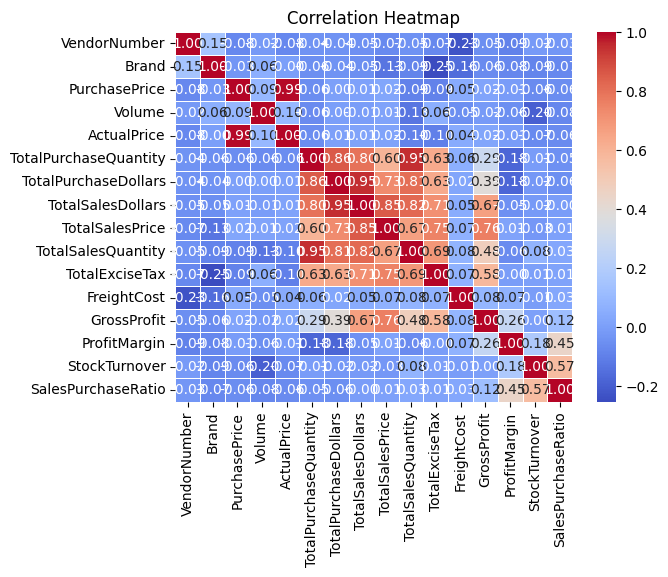

In [10]:
#correlation heatmap
plt.Figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f", cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()



# Data analysis
* identify brands that needs promotional or pricing adjustments which exhibit lower but higher profit margin.

In [11]:
brand_performance=df.groupby("Description").agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'      
}).reset_index()

In [12]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,12 Days of Pearls Gift Set,259.74,0.972318
1,13th Colony Sthrn Corn Whsky,149.95,0.893765
2,1800 Select Silver Tequila,299.90,0.727509
3,2 Copas Spain White,119.88,0.333333
4,4 Orange Vodka,175.92,0.612324
...,...,...,...
965,Z-52 Znfdl Lodi Old Vines,1262.42,0.987667
966,Zardetto Pros di Coneg Brut,163.20,0.761765
967,Zhenka Vodka 80 Proof,140.64,0.782992
968,Zinsane Znfdl Lodi,8125.83,0.975230


In [13]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [14]:
low_sales_threshold

np.float64(117.98)

In [15]:
high_margin_threshold

np.float64(0.8642455041969913)

In [16]:
#filter brands with low sales but high profit margin
target_brands= brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >=high_margin_threshold)
]
print("Brands with Low sales nut high profit margin")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low sales nut high profit margin


,Description,TotalSalesDollars,ProfitMargin
915,Tracia Syrah,44.94,0.884958
64,Bacardi Oakheart Spiced Trav,59.94,0.875542
272,Chicken & Turkey Cotes du Rh,59.94,0.909910
349,Dr McGillicuddy's Apple Pie,62.72,0.962691
837,St Elder Elderflower Liqueur,66.33,0.914368
46,Aresti Pnt Nr Curico Vly,74.85,0.956179
324,DeKuyper Buttershots Trav,76.93,0.907188
900,Three Olives Grape Vodka,80.19,0.991146
838,St Germain Liqueur,89.94,0.876584
699,Piehole Apple Pie,98.01,0.955923


In [17]:
brand_performance=brand_performance['TotalSalesDollars']<1000

In [18]:
print(type(brand_performance))


<class 'pandas.core.series.Series'>


In [19]:
brand_performance = df[['TotalSalesDollars', 'ProfitMargin']]  # ✅ DataFrame with selected columns


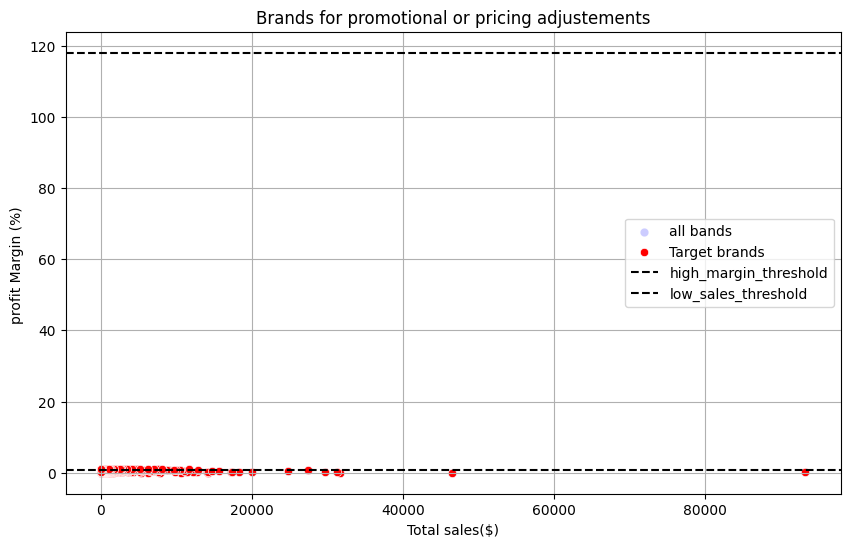

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x="TotalSalesDollars",y= 'ProfitMargin', color='blue', label="all bands",alpha=0.2 )
sns.scatterplot(data=brand_performance, x="TotalSalesDollars",y= 'ProfitMargin', color='red',label="Target brands" )

plt.axhline(high_margin_threshold, linestyle='--',color='black',label="high_margin_threshold")
plt.axhline(low_sales_threshold, linestyle='--',color='black',label="low_sales_threshold")

plt.xlabel("Total sales($)")
plt.ylabel("profit Margin (%) ")
plt.title("Brands for promotional or pricing adjustements")
plt.legend()
plt.grid(True)
plt.show()

which vendors and brands demonstrate the highest saless performance

In [21]:
def format_dollars(value):
    if value >=1_000_000:
        return f"{value / 1_000_000:2f}M" 
    elif value>=1_000:
        return f"{value /1_000:2f}K"
    else:
        return str(value)     

In [22]:
#Top vendors & brands by sales performance
top_vendors =df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands =df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
MARTIGNETTI COMPANIES         243980.10
CONSTELLATION BRANDS INC      180305.21
ULTRA BEVERAGE COMPANY LLP    148726.20
M S WALKER INC                117693.77
PERFECTA WINES                114277.24
BACARDI USA INC                61602.49
BROWN-FORMAN CORP              46884.09
DIAGEO NORTH AMERICA INC       42011.94
JIM BEAM BRANDS COMPANY        41429.49
SOUTHERN WINE & SPIRITS NE     40497.96
Name: TotalSalesDollars, dtype: float64

In [23]:
top_brands

Description
Simi Chard                      93369.42
Simi Cab Svgn                   46523.13
Banfi Centine Mntcln Tscna      31728.09
Rodney Strong Cab Svgn          31245.60
Ch La Rousseliere St Estephe    29698.02
Buehler Chard RRV               27397.25
Madison's Ranch Cab Svgn        24797.91
Rodney Strong Chard             20080.57
Cava Mistinguett Brut           18241.17
Bacardi Twin Pack 2/750mls      17331.33
Name: TotalSalesDollars, dtype: float64

In [24]:
top_brands.apply(lambda x: format_dollars(x))

Description
Simi Chard                      93.369420K
Simi Cab Svgn                   46.523130K
Banfi Centine Mntcln Tscna      31.728090K
Rodney Strong Cab Svgn          31.245600K
Ch La Rousseliere St Estephe    29.698020K
Buehler Chard RRV               27.397250K
Madison's Ranch Cab Svgn        24.797910K
Rodney Strong Chard             20.080570K
Cava Mistinguett Brut           18.241170K
Bacardi Twin Pack 2/750mls      17.331330K
Name: TotalSalesDollars, dtype: object

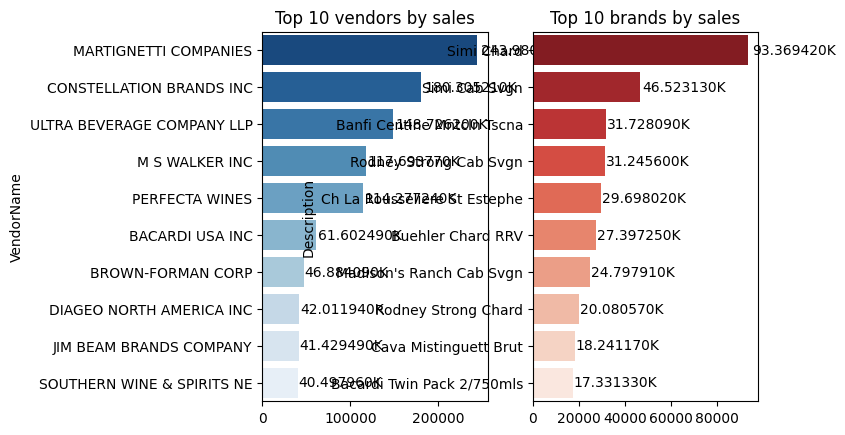

In [25]:
plt.Figure(figsize=(15,5))

#plot for top vendors
plt.subplot(1, 2, 1)
ax1=sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")
plt.title("Top 10 vendors by sales")

for bar in ax1.patches:
    ax1.text(bar.get_width()+ (bar.get_width() * 0.02),
             bar.get_y() +bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left',va='center', fontsize=10, color='black')

#plot for top brands
plt.subplot(1,2,2)
ax2=sns.barplot(y=top_brands.index.astype(str), x=top_brands.values,palette="Reds_r")
plt.title("Top 10 brands by sales")

for bar in ax2.patches:
    ax2.text(bar.get_width()+ (bar.get_width() * 0.02),
             bar.get_y() +bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left',va='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()    
    


which vendors contribute the most to total purchase dollars?

In [26]:
vendor_performance=df.groupby('VendorName').agg({
          'TotalPurchaseDollars':sum,
          'GrossProfit':'sum',
          'TotalSalesDollars':'sum'
}).reset_index()

In [27]:
vendor_performance.head()

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ALISA CARR BEVERAGES,2409.40,2871.96,5281.36
1,ATLANTIC IMPORTING COMPANY,620.40,129.35,749.75
2,BACARDI USA INC,30939.14,30663.35,61602.49
3,BANFI PRODUCTS CORP,33925.17,3667.98,37593.15
4,BROWN-FORMAN CORP,9493.91,37390.18,46884.09


In [28]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()

In [29]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
9,CONSTELLATION BRANDS INC,155184.04,25121.17,180305.21,0.21
33,MARTIGNETTI COMPANIES,106115.65,137864.45,243980.10,0.14
42,PERFECTA WINES,65884.50,48392.74,114277.24,0.09
63,ULTRA BEVERAGE COMPANY LLP,56969.42,91756.78,148726.20,0.08
31,M S WALKER INC,46582.51,71111.26,117693.77,0.06
...,...,...,...,...,...
32,MARSALLE COMPANY,78.78,1378.41,1457.19,0.00
20,FANTASY FINE WINES CORP,64.32,15.58,79.90,0.00
6,CAPSTONE INTERNATIONAL,54.64,173.24,227.88,0.00
68,WEIN BAUER INC,36.56,5.38,41.94,0.00


In [30]:
vendor_performance.shape

(72, 5)

In [31]:
#Display top 10 vendor
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars'] =top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)

In [32]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
9,CONSTELLATION BRANDS INC,155.184040K,25.121170K,180.305210K,0.21
33,MARTIGNETTI COMPANIES,106.115650K,137.864450K,243.980100K,0.14
42,PERFECTA WINES,65.884500K,48.392740K,114.277240K,0.09
63,ULTRA BEVERAGE COMPANY LLP,56.969420K,91.756780K,148.726200K,0.08
31,M S WALKER INC,46.582510K,71.111260K,117.693770K,0.06
3,BANFI PRODUCTS CORP,33.925170K,3.667980K,37.593150K,0.05
2,BACARDI USA INC,30.939140K,30.663350K,61.602490K,0.04
14,DIAGEO NORTH AMERICA INC,20.878560K,21.133380K,42.011940K,0.03
26,JIM BEAM BRANDS COMPANY,18.693170K,22.736320K,41.429490K,0.03
55,STATE WINE & SPIRITS,15.259940K,22.062770K,37.322710K,0.02


In [33]:
top_vendors['PurchaseContribution%'].sum()

np.float64(0.75)

In [34]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
9,CONSTELLATION BRANDS INC,155.184040K,25.121170K,180.305210K,0.21,0.21
33,MARTIGNETTI COMPANIES,106.115650K,137.864450K,243.980100K,0.14,0.35
42,PERFECTA WINES,65.884500K,48.392740K,114.277240K,0.09,0.44
63,ULTRA BEVERAGE COMPANY LLP,56.969420K,91.756780K,148.726200K,0.08,0.52
31,M S WALKER INC,46.582510K,71.111260K,117.693770K,0.06,0.58
3,BANFI PRODUCTS CORP,33.925170K,3.667980K,37.593150K,0.05,0.63
2,BACARDI USA INC,30.939140K,30.663350K,61.602490K,0.04,0.67
14,DIAGEO NORTH AMERICA INC,20.878560K,21.133380K,42.011940K,0.03,0.70
26,JIM BEAM BRANDS COMPANY,18.693170K,22.736320K,41.429490K,0.03,0.73
55,STATE WINE & SPIRITS,15.259940K,22.062770K,37.322710K,0.02,0.75


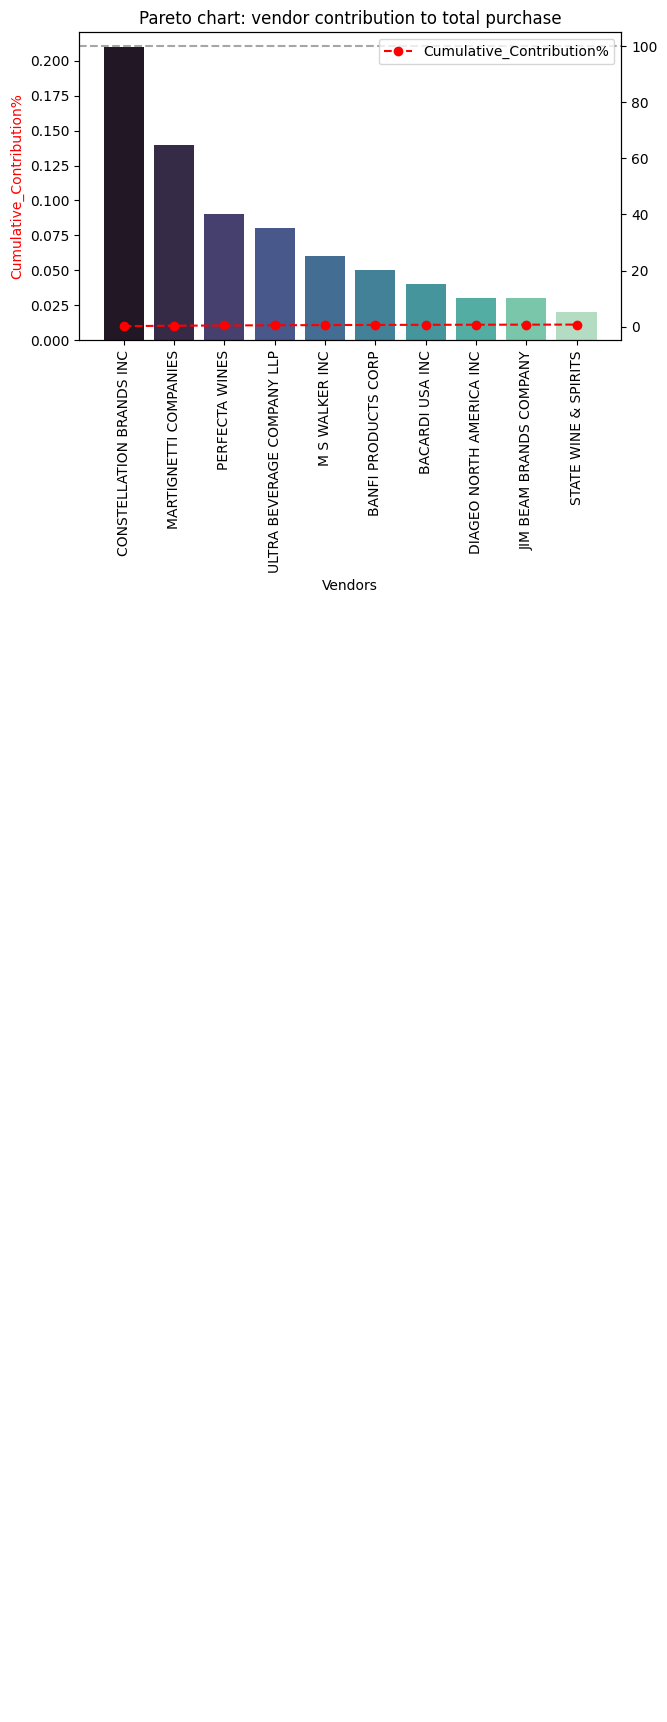

In [35]:

fig, ax1 = plt.subplots(figsize=(7,4))

#bar plot for purchase contribution%
sns.barplot(x=top_vendors['VendorName'],y=top_vendors['PurchaseContribution%'],palette="mako",ax=ax1)

for i,value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i,value -1,str(value)+'%',ha='center', fontsize=10,color='white')

#line plot for cumulative contribution%
ax2=ax1.twinx()
ax2.plot(top_vendors['VendorName'],top_vendors['Cumulative_Contribution%'],color='red',marker='o', linestyle='dashed', label='Cumulative_Contribution%') 

ax1.set_xticklabels(top_vendors['VendorName'],rotation=90)
ax1.set_ylabel('PurchaseContribution%',color='blue')
ax1.set_ylabel('Cumulative_Contribution%',color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto chart: vendor contribution to total purchase')

ax2.axhline(y=100,color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.show()


how much of total procurement is dependent on the top vendor?

In [36]:
print(f"total purchase contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

total purchase contribution of top 10 vendors is 0.75 %


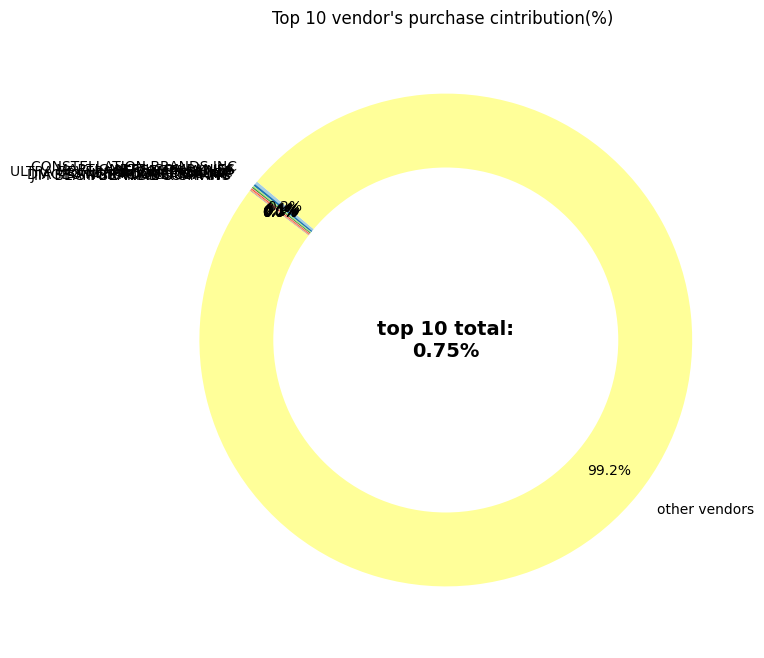

In [37]:
vendors=list(top_vendors['VendorName'].values)
purchase_contribution =list(top_vendors['PurchaseContribution%'].values)
total_contribution= sum(purchase_contribution)
remaining_contribution=100 - total_contribution

# append other vendors category
vendors.append("other vendors")
purchase_contribution.append(remaining_contribution)

#donut chart
fig, ax =plt.subplots(figsize=(8,8))
wedges, texts, autotexts=ax.pie(purchase_contribution, labels=vendors,autopct='%1.1f%%',
                                startangle=140,pctdistance=0.85, colors=plt.cm.Paired.colors)

#draw a white circle in the center to create a "donut" effect
centre_circle= plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

#addtotal contribution annotation in the center
plt.text(0, 0, f"top 10 total:\n{total_contribution:.2f}%", fontsize=14,fontweight='bold', ha='center', va='center')
plt.title("Top 10 vendor's purchase cintribution(%) ")
plt.show()



# does purchasing in bulk reduce the unit price, and what is the optiional purchasse volume for cost ssaving?

In [38]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] /df['TotalPurchaseQuantity']

In [39]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio,UnitPurchasePrice
0,1392,CONSTELLATION BRANDS INC,6650,Simi Chard,7.38,750.0,14.99,11199,82648.62,93369.42,13558.87,8458.0,949.79,79528.99,10720.80,0.114821,0.102337,1.129715,7.38
1,1392,CONSTELLATION BRANDS INC,22143,Simi Cab Svgn,10.52,750.0,18.99,4194,44120.88,46523.13,13703.56,2887.0,323.21,79528.99,2402.25,0.051636,0.065434,1.054447,10.52
2,516,BANFI PRODUCTS CORP,18152,Banfi Centine Mntcln Tscna,5.26,750.0,10.99,5723,30102.98,31728.09,7605.68,3891.0,436.17,8510.41,1625.11,0.051220,0.129256,1.053985,5.26
3,10754,PERFECTA WINES,25197,Ch La Rousseliere St Estephe,99.33,750.0,149.99,249,24733.17,29698.02,1199.92,198.0,22.24,28720.52,4964.85,0.167178,0.008005,1.200737,99.33
4,4425,MARTIGNETTI COMPANIES,8781,Rodney Strong Cab Svgn,10.32,750.0,15.99,2241,23127.12,31245.60,11934.97,1840.0,205.53,144929.24,8118.48,0.259828,0.079560,1.351037,10.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,90024,VINILANDIA USA,46135,Aresti Pnt Nr Curico Vly,3.28,750.0,10.99,1,3.28,74.85,39.92,15.0,1.68,2802.64,71.57,0.956179,4.573171,22.820122,3.28
978,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,750.0,4.99,2,2.64,5.97,5.97,3.0,0.33,27100.41,3.33,0.557789,1.136364,2.261364,1.32
979,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,50.0,0.49,6,2.34,62.72,0.98,128.0,6.72,50293.62,60.38,0.962691,54.700855,26.803419,0.39
980,9815,WINE GROUP INC,22407,Three Wishes Chard,2.25,750.0,3.29,1,2.25,3.29,3.29,1.0,0.11,27100.41,1.04,0.316109,0.444444,1.462222,2.25


In [40]:
df['OrderSize'] =pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=["Small","Medium", "Large"])

In [41]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,11199
1,Large,4194
2,Large,5723
3,Large,249
4,Large,2241
...,...,...
977,Small,1
978,Small,2
979,Small,6
980,Small,1


In [42]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,35.900600
Medium,20.687564
Large,11.248938


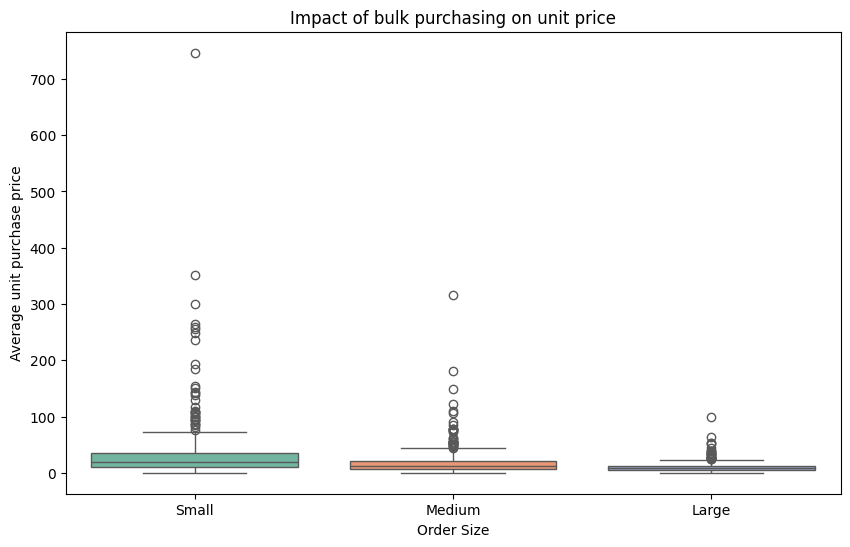

In [43]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='OrderSize', y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of bulk purchasing on unit price")
plt.xlabel("Order Size")
plt.ylabel("Average unit purchase price")
plt.show()

which vendors have low inventory turnover, indicating excess stock and slow -moving products?

In [44]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.033403
VRANKEN AMERICA,0.034837
ATLANTIC IMPORTING COMPANY,0.040297
EDRINGTON AMERICAS,0.044442
STE MICHELLE WINE ESTATES,0.053154
OLE SMOKY DISTILLERY LLC,0.054339
SEA BREEZE CELLARS LLC,0.056402
WILLIAM GRANT & SONS INC,0.057400
MOET HENNESSY USA INC,0.057578


* How much captial is locked in unsold inventory per vendor and which vendors contribute the most to it.

In [45]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: -250988.90000000002


In [46]:
#Aggregate captial locked per vendor
inventory_value_per_vendor =df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#sort vendor with the highest locked capital
inventory_value_per_vendor= inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)


,VendorName,UnsoldInventoryValue
9,CONSTELLATION BRANDS INC,35.233370K
3,BANFI PRODUCTS CORP,9.885870K
62,TRINCHERO FAMILY ESTATES,3.798270K
23,FREDERICK WILDMAN & SONS,3.105220K
71,WINE GROUP INC,2.583870K
53,SIDNEY FRANK IMPORTING CO,561.55
64,VINEXTRA INC,201.57
39,NICHE W & S,192.72
61,TREASURY WINE ESTATES,190.9
40,OLE SMOKY DISTILLERY LLC,135.6


what is the 95% confidence intervals for profit margins of top-performing and low-performing vendor.

In [47]:
top_threshold =df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

In [48]:
top_vendors =df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors =df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [49]:
top_vendors

0      0.114821
1      0.051636
2      0.051220
3      0.167178
4      0.259828
         ...   
812    0.969162
814    0.978776
916    0.987631
923    0.987667
938    0.988372
Name: ProfitMargin, Length: 246, dtype: float64

In [50]:
low_vendors

498    0.073206
505    0.149802
518    0.001672
533    0.117396
553    0.053519
         ...   
977    0.956179
978    0.557789
979    0.962691
980    0.316109
981    0.991146
Name: ProfitMargin, Length: 246, dtype: float64

In [51]:
def confidence_interval(data, confidence=0.95):
    mean_val =np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) #standard error
    t_critical =stats.t.ppf((1 + confidence) / 2, df=len(data)-1)    
    margin_of_error =t_critical * std_err
    return mean_val, mean_val - margin_of_error,mean_val +margin_of_error  

Top Vendors 95% CI: (0.57, 0.64), Mean: 0.61
Low Vendors 95% CI: (0.44, 0.50), Mean: 0.47


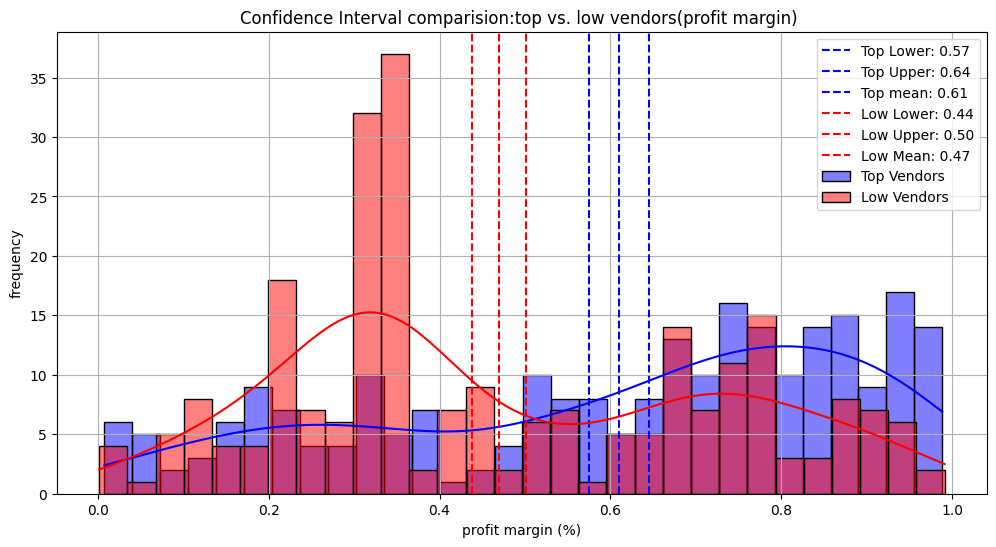

In [52]:
top_mean, top_lower, top_upper =confidence_interval(top_vendors)
low_mean, low_lower, low_upper =confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12,6))

#Top vendors plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="--", label=f"Top mean: {top_mean:.2f}")

#low vendors plot
sns.histplot(low_vendors,kde=True, color='red', bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="--", label=f"Low Mean: {low_mean:.2f}")

#finalize plot
plt.title("Confidence Interval comparision:top vs. low vendors(profit margin) ")
plt.xlabel("profit margin (%)")
plt.ylabel("frequency")
plt.legend()
plt.legend()
plt.grid(True)
plt.show()



In [53]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)

top_vendors=df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors=df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

#perform  two-sasmple t- test
t_stat, p_value =ttest_ind(top_vendors, low_vendors, equal_var=False)

#print result
print(f"T-Statistic: {t_stat:.4f}, p-value:{p_value:.4f}")
if p_value<0.5:
    print("reject He: there is a significant difference in profit margin between top and low-performing vendor.") 
else:
    print("fail to reject He:no significant difference in profit margin ")         

T-Statistic: 5.8581, p-value:0.0000
reject He: there is a significant difference in profit margin between top and low-performing vendor.
